In [2]:
pip install prophet


  Using cached importlib_resources-6.5.2-py3-none-any.whl.metadata (3.9 kB)
   ---------------------------------------- 0.0/13.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/13.3 MB ? eta -:--:--
    --------------------------------------- 0.3/13.3 MB ? eta -:--:--
   - -------------------------------------- 0.5/13.3 MB 1.0 MB/s eta 0:00:13
   -- ------------------------------------- 0.8/13.3 MB 1.1 MB/s eta 0:00:12
   -- ------------------------------------- 0.8/13.3 MB 1.1 MB/s eta 0:00:12
   --- ------------------------------------ 1.0/13.3 MB 1.0 MB/s eta 0:00:12
   --- ------------------------------------ 1.3/13.3 MB 1.1 MB/s eta 0:00:12
   ---- ----------------------------------- 1.6/13.3 MB 1.1 MB/s eta 0:00:11
   ----- ---------------------------------- 1.8/13.3 MB 1.1 MB/s eta 0:00:11
   ----- ---------------------------------- 1.8/13.3 MB 1.1 MB/s eta 0:00:11
   ------ --------------------------------- 2.1/13.3 MB 1.0 MB/s eta 0:00:12
   ------- ----------

In [4]:
# src/prophet_baseline.py
from prophet import Prophet
import pandas as pd
from pathlib import Path

# Absolute path to your project root
PROJECT_ROOT = Path("C:/Users/dedee/Downloads/epidemic-project")

# Path to panel CSV
PANEL_CSV = PROJECT_ROOT / "data_curated/panel_state_daily.csv"

# Read data
panel = pd.read_csv(PANEL_CSV, parse_dates=['Date'])
states = panel['state'].unique()
out = []

for st in states:
    sub = panel[panel['state']==st].sort_values('Date')[['Date','active']].rename(columns={'Date':'ds','active':'y'})
    if len(sub) < 30:  # skip tiny series
        continue
    train = sub.iloc[:-7]  # train on all but last 7 days
    m = Prophet(daily_seasonality=False)
    m.fit(train)
    future = m.make_future_dataframe(periods=7)
    fc = m.predict(future)
    # evaluate on last 7 days
    pred = fc.set_index('ds').loc[sub['ds'].iloc[-7:]]['yhat'].values
    truth = sub['y'].values[-7:]
    for i in range(len(pred)):
        out.append({"state":st, "date":str(sub['ds'].iloc[-7+i]), "pred":float(pred[i]), "true":float(truth[i])})

# Save forecast
OUT_CSV = PROJECT_ROOT / "data_curated/prophet_oneweek_forecast.csv"
pd.DataFrame(out).to_csv(OUT_CSV, index=False)
print("Saved forecast to:", OUT_CSV)


23:59:22 - cmdstanpy - INFO - Chain [1] start processing
23:59:23 - cmdstanpy - INFO - Chain [1] done processing
23:59:23 - cmdstanpy - INFO - Chain [1] start processing
23:59:23 - cmdstanpy - INFO - Chain [1] done processing
23:59:24 - cmdstanpy - INFO - Chain [1] start processing
23:59:24 - cmdstanpy - INFO - Chain [1] done processing
23:59:24 - cmdstanpy - INFO - Chain [1] start processing
23:59:24 - cmdstanpy - INFO - Chain [1] done processing
23:59:25 - cmdstanpy - INFO - Chain [1] start processing
23:59:25 - cmdstanpy - INFO - Chain [1] done processing
23:59:25 - cmdstanpy - INFO - Chain [1] start processing
23:59:25 - cmdstanpy - INFO - Chain [1] done processing
23:59:25 - cmdstanpy - INFO - Chain [1] start processing
23:59:25 - cmdstanpy - INFO - Chain [1] done processing
23:59:26 - cmdstanpy - INFO - Chain [1] start processing
23:59:26 - cmdstanpy - INFO - Chain [1] done processing
23:59:26 - cmdstanpy - INFO - Chain [1] start processing
23:59:26 - cmdstanpy - INFO - Chain [1]

Saved forecast to: C:\Users\dedee\Downloads\epidemic-project\data_curated\prophet_oneweek_forecast.csv


In [6]:
import pandas as pd

# load the CSV
df = pd.read_csv("C:/Users/dedee/Downloads/epidemic-project/data_curated/prophet_oneweek_forecast.csv")

# show first 5 rows
df.head()


,state,date,pred,true
0,Andaman and Nicobar Islands,2021-08-05 00:00:00,70.957111,4.0
1,Andaman and Nicobar Islands,2021-08-06 00:00:00,72.042068,4.0
2,Andaman and Nicobar Islands,2021-08-07 00:00:00,72.022674,4.0
3,Andaman and Nicobar Islands,2021-08-08 00:00:00,71.515515,6.0
4,Andaman and Nicobar Islands,2021-08-09 00:00:00,70.719643,7.0


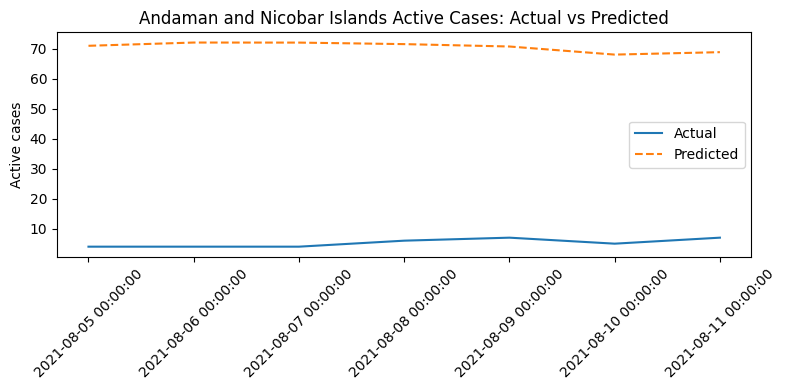

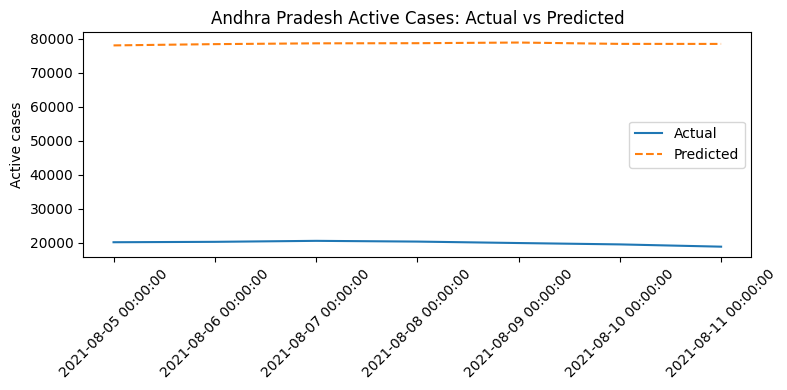

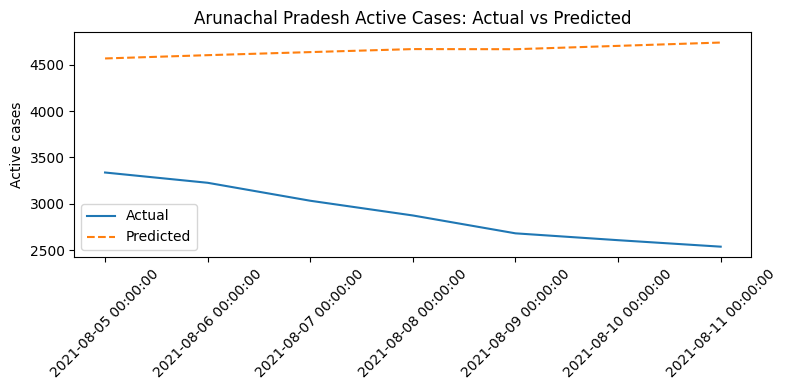

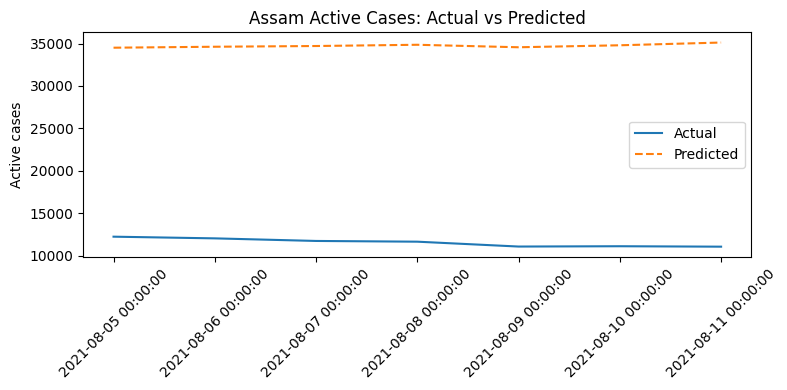

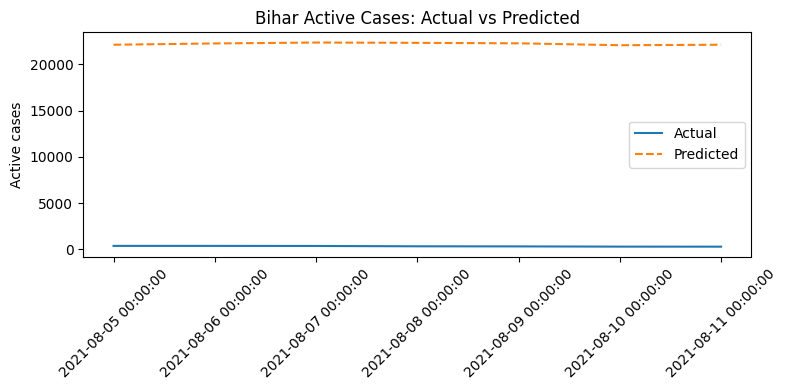

In [5]:
import matplotlib.pyplot as plt

for st in states[:5]:  # example: first 5 states
    df = pd.DataFrame(out)
    sub = df[df['state']==st]
    plt.figure(figsize=(8,4))
    plt.plot(sub['date'], sub['true'], label='Actual')
    plt.plot(sub['date'], sub['pred'], label='Predicted', linestyle='--')
    plt.title(f"{st} Active Cases: Actual vs Predicted")
    plt.xticks(rotation=45)
    plt.ylabel("Active cases")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [4]:

import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path("C:/Users/dedee/Downloads/epidemic-project")
OUT_CSV = PROJECT_ROOT / "data_curated/prophet_oneweek_forecast.csv"

# load saved prophet outputs
out_df = pd.read_csv(OUT_CSV, parse_dates=["date"])

# binarize truth
threshold = out_df["true"].median()
out_df["true_label"] = (out_df["true"] > threshold).astype(int)

# normalize predictions
out_df["prob"] = out_df["pred"] / (out_df["pred"].max() + 1e-6)

# save processed version
final_csv = PROJECT_ROOT / "results" / "predictions_with_truth.csv"
out_df[["date", "state", "prob", "true_label"]].to_csv(final_csv, index=False)

print("✅ Processed forecast saved:", final_csv)
print(out_df.head())



✅ Processed forecast saved: C:\Users\dedee\Downloads\epidemic-project\results\predictions_with_truth.csv
                         state       date       pred  true  true_label  \
0  Andaman and Nicobar Islands 2021-08-05  70.957111   4.0           0   
1  Andaman and Nicobar Islands 2021-08-06  72.042068   4.0           0   
2  Andaman and Nicobar Islands 2021-08-07  72.022674   4.0           0   
3  Andaman and Nicobar Islands 2021-08-08  71.515515   6.0           0   
4  Andaman and Nicobar Islands 2021-08-09  70.719643   7.0           0   

       prob  
0  0.000276  
1  0.000280  
2  0.000280  
3  0.000278  
4  0.000275  
